# ChurnInsight — Logistic Regression + SMOTE (Contrato v4) — FINAL

> **Objetivo:** versión **post-MVP** (roadmap) con **Regresión Logística + SMOTE**, alineada al **Contrato v4**, lista para **Run All** en Google Colab/Jupyter.

- Modelo: **Logistic Regression** (interpretable) + **SMOTE** (balanceo)
- Salida: `forecast`, `probability`, `top_features` (explicabilidad)
- Artefactos: `joblib` + `metadata.json` + `CSV demo para Power BI`

Este notebook **no reemplaza** el MVP v3. Es una **versión de roadmap**, separada y compatible con backend vía contrato v4.

## 1) Setup (imports + configuración)

Este bloque instala dependencias si faltan (Colab), define parámetros (seed/threshold) y rutas de salida.

In [1]:
import sys, os, json, warnings, datetime
warnings.filterwarnings("ignore")

# En Colab, a veces falta imbalanced-learn
try:
    import imblearn  # noqa
except Exception:
    !pip -q install imbalanced-learn

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

SEED = 42
np.random.seed(SEED)

# Umbral de negocio (alineado con backend)
THRESHOLD = 0.22

ARTIFACT_DIR = "models"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

MODEL_FILENAME = "churn_logreg_smote_v4.joblib"
METADATA_FILENAME = "metadata_logreg_smote_v4.json"
POWERBI_CSV_FILENAME = "predictions_powerbi_demo_v4.csv"

MODEL_PATH = os.path.join(ARTIFACT_DIR, MODEL_FILENAME)
METADATA_PATH = os.path.join(ARTIFACT_DIR, METADATA_FILENAME)
POWERBI_CSV_PATH = os.path.join(ARTIFACT_DIR, POWERBI_CSV_FILENAME)

print("✅ Setup listo")
print("Model path:", MODEL_PATH)
print("Metadata path:", METADATA_PATH)
print("PowerBI CSV path:", POWERBI_CSV_PATH)


✅ Setup listo
Model path: models/churn_logreg_smote_v4.joblib
Metadata path: models/metadata_logreg_smote_v4.json
PowerBI CSV path: models/predictions_powerbi_demo_v4.csv


## 2) Dataset (real si existe, si no: demo sintético)

El notebook intenta cargar un dataset típico (`Churn_Modelling.csv`). Si no lo encuentra, genera un dataset demo con las columnas del contrato v4 + objetivo `Exited`.

In [2]:
CANDIDATE_PATHS = [
    "Churn_Modelling.csv",
    "data/Churn_Modelling.csv",
    "data/churn.csv",
    "churn.csv",
]

df = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f"✅ Dataset cargado desde: {p} | shape={df.shape}")
        break

if df is None:
    n = 10000
    geos = np.random.choice(["Spain","France","Germany"], size=n, p=[0.45,0.35,0.20])
    gender = np.random.choice(["Male","Female"], size=n, p=[0.55,0.45])
    age = np.random.randint(18, 101, size=n)
    credit = np.random.randint(100, 1001, size=n)
    balance = np.round(np.random.gamma(shape=2.0, scale=1500.0, size=n), 2)
    salary = np.round(np.random.gamma(shape=2.0, scale=20000.0, size=n), 2)
    tenure = np.random.randint(0, 21, size=n)
    numprod = np.random.choice([1,2,3,4], size=n, p=[0.55,0.30,0.10,0.05])
    sat = np.random.choice([1,2,3,4,5], size=n, p=[0.10,0.20,0.35,0.25,0.10])
    is_active = np.random.choice([0,1], size=n, p=[0.40,0.60])
    has_card = np.random.choice([0,1], size=n, p=[0.35,0.65])
    complain = np.random.choice([0,1], size=n, p=[0.80,0.20])

    logit = (
        -2.0
        + 0.02*(age-40)
        + 0.001*(balance/100)
        + 0.8*complain
        - 0.6*is_active
        + 0.15*(numprod-1)
        + 0.002*((1000-credit)/10)
    )
    p_true = 1/(1+np.exp(-logit))
    exited = (np.random.rand(n) < p_true).astype(int)

    df = pd.DataFrame({
        "Geography": geos,
        "Gender": gender,
        "Age": age,
        "CreditScore": credit,
        "Balance": balance,
        "EstimatedSalary": salary,
        "Tenure": tenure,
        "NumOfProducts": numprod,
        "SatisfactionScore": sat,
        "IsActiveMember": is_active,
        "HasCrCard": has_card,
        "Complain": complain,
        "Exited": exited
    })
    print(f"✅ Dataset DEMO generado | shape={df.shape}")

if "Exited" not in df.columns:
    if "Churn" in df.columns:
        df = df.rename(columns={"Churn":"Exited"})
    elif "target" in df.columns:
        df = df.rename(columns={"target":"Exited"})

assert "Exited" in df.columns, "No se encontró columna target ('Exited')."
df.head()


✅ Dataset DEMO generado | shape=(10000, 13)


,Geography,Gender,Age,CreditScore,Balance,EstimatedSalary,Tenure,NumOfProducts,SatisfactionScore,IsActiveMember,HasCrCard,Complain,Exited
0,Spain,Male,19,375,5783.45,23439.01,6,1,4,1,1,0,0
1,Germany,Male,21,810,2390.81,33833.26,13,4,2,0,0,1,0
2,France,Male,62,558,1389.80,16372.95,4,1,5,0,1,0,0
3,France,Female,30,552,1811.51,31637.91,18,1,4,0,1,0,0
4,Spain,Male,72,512,2246.70,77132.63,16,1,3,1,1,0,0


## 3) Contrato v4 (Backend camelCase → DS PascalCase) + validación

Incluye funciones:
- `contract_v4_to_df(payload)`
- `validate_domain_v4(payload)`

In [3]:
CONTRACT_V4_FIELDS = [
    "geography", "gender", "age", "creditScore", "balance", "estimatedSalary",
    "tenure", "numOfProducts", "satisfactionScore", "isActiveMember",
    "hasCrCard", "complain"
]

V4_REQUIRED = {"geography","age","creditScore","balance","numOfProducts","satisfactionScore","isActiveMember","complain"}
V4_OPTIONAL = set(CONTRACT_V4_FIELDS) - V4_REQUIRED

V4_TO_DS = {
    "geography": "Geography",
    "gender": "Gender",
    "age": "Age",
    "creditScore": "CreditScore",
    "balance": "Balance",
    "estimatedSalary": "EstimatedSalary",
    "tenure": "Tenure",
    "numOfProducts": "NumOfProducts",
    "satisfactionScore": "SatisfactionScore",
    "isActiveMember": "IsActiveMember",
    "hasCrCard": "HasCrCard",
    "complain": "Complain",
}

def _to_bool01(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    if isinstance(x, bool):
        return int(x)
    if isinstance(x, (int, np.integer)):
        return 1 if int(x) != 0 else 0
    if isinstance(x, str):
        s = x.strip().lower()
        if s in {"true","t","yes","y","1"}: return 1
        if s in {"false","f","no","n","0"}: return 0
    try:
        return 1 if float(x) != 0 else 0
    except Exception:
        return np.nan

def contract_v4_to_df(payload: dict) -> pd.DataFrame:
    row = {k: payload.get(k, np.nan) for k in CONTRACT_V4_FIELDS}
    for b in ["isActiveMember","hasCrCard","complain"]:
        row[b] = _to_bool01(row.get(b, np.nan))
    mapped = {V4_TO_DS[k]: row[k] for k in CONTRACT_V4_FIELDS}
    return pd.DataFrame([mapped])

def validate_domain_v4(payload: dict):
    w = []
    missing = [k for k in V4_REQUIRED if k not in payload or payload.get(k, None) is None]
    if missing:
        w.append(f"Faltan campos obligatorios: {missing}")

    geo = payload.get("geography", None)
    if geo is not None and str(geo) not in {"Spain","France","Germany"}:
        w.append("geography fuera de dominio esperado: Spain/France/Germany")

    gen = payload.get("gender", None)
    if gen is not None and str(gen) not in {"Male","Female"}:
        w.append("gender fuera de dominio esperado: Male/Female")

    def _check_int(name, lo, hi):
        v = payload.get(name, None)
        if v is None: return
        try:
            vi = int(v)
            if vi < lo or vi > hi:
                w.append(f"{name} fuera de rango [{lo},{hi}]")
        except Exception:
            w.append(f"{name} no es int válido")

    def _check_float(name, lo=0.0):
        v = payload.get(name, None)
        if v is None: return
        try:
            vf = float(v)
            if vf < lo:
                w.append(f"{name} debe ser ≥ {lo}")
        except Exception:
            w.append(f"{name} no es float válido")

    _check_int("age", 18, 100)
    _check_int("creditScore", 100, 1000)
    _check_float("balance", 0.0)
    _check_float("estimatedSalary", 0.0)
    _check_int("tenure", 0, 20)
    _check_int("numOfProducts", 1, 4)
    _check_int("satisfactionScore", 1, 5)

    for b in ["isActiveMember","hasCrCard","complain"]:
        if b in payload and payload[b] is not None:
            if _to_bool01(payload[b]) not in {0,1}:
                w.append(f"{b} debe ser booleano (true/false) o 0/1")
    return w

example_v4 = {
  "geography":"Spain","gender":"Male","age":42,"creditScore":650,"balance":1200.5,
  "estimatedSalary":45000,"tenure":6,"numOfProducts":2,"satisfactionScore":2,
  "isActiveMember":True,"hasCrCard":True,"complain":False
}
print("Warnings:", validate_domain_v4(example_v4))
contract_v4_to_df(example_v4)


Warnings: []


,Geography,Gender,Age,CreditScore,Balance,EstimatedSalary,Tenure,NumOfProducts,SatisfactionScore,IsActiveMember,HasCrCard,Complain
0,Spain,Male,42,650,1200.5,45000,6,2,2,1,1,0


## 4) Preparación y pipeline (preprocess + SMOTE + Logistic Regression)

In [4]:
FEATURES_DS = [
    "Geography","Gender","Age","CreditScore","Balance","EstimatedSalary","Tenure",
    "NumOfProducts","SatisfactionScore","IsActiveMember","HasCrCard","Complain"
]

# Intento mapear si el dataset viene en camelCase
alt_map = {
    "geography":"Geography","gender":"Gender","age":"Age","creditScore":"CreditScore",
    "balance":"Balance","estimatedSalary":"EstimatedSalary","tenure":"Tenure",
    "numOfProducts":"NumOfProducts","satisfactionScore":"SatisfactionScore",
    "isActiveMember":"IsActiveMember","hasCrCard":"HasCrCard","complain":"Complain"
}
for src,dst in alt_map.items():
    if src in df.columns and dst not in df.columns:
        df = df.rename(columns={src:dst})

# Crea faltantes como NaN (imputable)
for c in FEATURES_DS:
    if c not in df.columns:
        df[c] = np.nan

X = df[FEATURES_DS].copy()
y = df["Exited"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

categorical = ["Geography","Gender"]
numeric = [c for c in FEATURES_DS if c not in categorical]

numeric_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric),
        ("cat", categorical_pipe, categorical)
    ],
    remainder="drop"
)

smote = SMOTE(random_state=SEED, k_neighbors=5)
clf = LogisticRegression(max_iter=2000, solver="lbfgs")

pipe = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", smote),
    ("model", clf)
])

pipe


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'CreditScore',
                                                   'Balance', 'EstimatedSalary',
                                                   'Tenure', 'NumOfProducts',
                                                   'SatisfactionScore',
                                                   'IsActiveMember',
                                                   'HasCrCard', 'Complain']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Geography', 'Gender'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000))])

## 5) Entrenamiento + evaluación

=== Evaluación con threshold=0.50 (referencia) ===
              precision    recall  f1-score   support

           0       0.88      0.65      0.75      1634
           1       0.28      0.62      0.39       366

    accuracy                           0.64      2000
   macro avg       0.58      0.63      0.57      2000
weighted avg       0.77      0.64      0.68      2000

Confusion matrix:
 [[1060  574]
 [ 140  226]]
ROC AUC: 0.6786


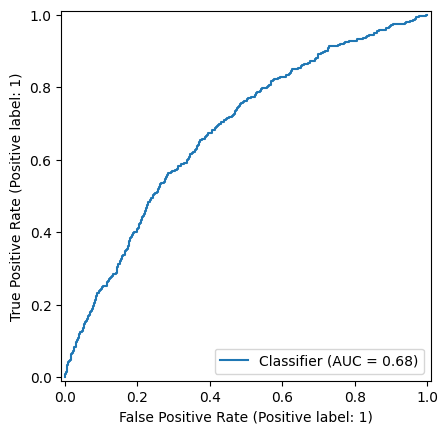

In [5]:
pipe.fit(X_train, y_train)

y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print("=== Evaluación con threshold=0.50 (referencia) ===")
print(classification_report(y_test, y_pred_05))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_05))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))

try:
    RocCurveDisplay.from_predictions(y_test, y_proba)
except Exception as e:
    print("ROC curve no disponible:", e)


## 6) Threshold de negocio (por defecto 0.22)

In [6]:
y_pred_thr = (y_proba >= THRESHOLD).astype(int)

print(f"=== Evaluación con threshold={THRESHOLD:.2f} (negocio) ===")
print(classification_report(y_test, y_pred_thr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thr))


=== Evaluación con threshold=0.22 (negocio) ===
              precision    recall  f1-score   support

           0       0.94      0.09      0.16      1634
           1       0.19      0.98      0.32       366

    accuracy                           0.25      2000
   macro avg       0.57      0.53      0.24      2000
weighted avg       0.80      0.25      0.19      2000

Confusion matrix:
 [[ 146 1488]
 [   9  357]]


## 7) Explicabilidad (coeficientes) y top_features

In [7]:
def _get_feature_names(pre: ColumnTransformer):
    num_features = numeric
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(categorical).tolist()
    return list(num_features) + cat_features

def global_feature_importance(pipe, top_n=20):
    model = pipe.named_steps["model"]
    feats = _get_feature_names(pipe.named_steps["preprocess"])
    coefs = model.coef_.ravel()
    imp = pd.DataFrame({"feature":feats, "coef":coefs, "abs_coef":np.abs(coefs)})
    return imp.sort_values("abs_coef", ascending=False).head(top_n)

global_feature_importance(pipe, top_n=20)


,feature,coef,abs_coef
9,Complain,1.144977,1.144977
7,IsActiveMember,-0.722007,0.722007
14,Gender_Male,-0.261424,0.261424
10,Geography_France,-0.205091,0.205091
13,Gender_Female,-0.191081,0.191081
8,HasCrCard,-0.169675,0.169675
12,Geography_Spain,-0.164324,0.164324
11,Geography_Germany,-0.083091,0.083091
5,NumOfProducts,0.075938,0.075938
6,SatisfactionScore,-0.039501,0.039501


## 8) predict_v4(payload) — salida para backend

In [8]:
HUMAN_LABELS = {
    "Complain": "Tiene quejas",
    "IsActiveMember": "Cliente activo",
    "Balance": "Saldo",
    "CreditScore": "Puntaje de crédito",
    "Age": "Edad",
    "NumOfProducts": "Número de productos",
    "SatisfactionScore": "Satisfacción",
    "EstimatedSalary": "Salario estimado",
    "HasCrCard": "Tiene tarjeta",
    "Tenure": "Antigüedad",
    "Geography": "País",
    "Gender": "Género",
}

def _top_features_for_instance(pipe, X_one: pd.DataFrame, top_k=3):
    pre = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]
    feats = _get_feature_names(pre)
    coef = model.coef_.ravel()

    Xt = pre.transform(X_one)
    x_vec = Xt.toarray().ravel() if hasattr(Xt, "toarray") else np.array(Xt).ravel()

    contrib = coef * x_vec
    idx = np.argsort(np.abs(contrib))[::-1][:top_k]

    out = []
    for i in idx:
        f = feats[i]
        c = float(contrib[i])
        impact = "positivo" if c > 0 else "negativo"

        if f.startswith("Geography_"):
            base = "Geography"; val = f.replace("Geography_","")
        elif f.startswith("Gender_"):
            base = "Gender"; val = f.replace("Gender_","")
        else:
            base = f; val = str(X_one.iloc[0].get(base, ""))

        out.append({"name": HUMAN_LABELS.get(base, base), "value": val, "impact": impact})
    return out

def predict_v4(payload: dict, threshold: float = THRESHOLD, top_k: int = 3):
    warns = validate_domain_v4(payload)
    X_one = contract_v4_to_df(payload)
    proba = float(pipe.predict_proba(X_one)[:, 1][0])
    pred = int(proba >= threshold)

    return {
        "forecast": "Va a cancelar" if pred == 1 else "No va a cancelar",
        "probability": round(proba, 4),
        "top_features": _top_features_for_instance(pipe, X_one, top_k=top_k) if pred == 1 else [],
        "warnings": warns
    }

predict_v4(example_v4)


{'forecast': 'Va a cancelar',
 'probability': 0.261,
 'top_features': [{'name': 'Edad', 'value': '42', 'impact': 'positivo'},
  {'name': 'Cliente activo', 'value': '1', 'impact': 'negativo'},
  {'name': 'Género', 'value': 'Male', 'impact': 'negativo'}],
 'warnings': []}

## 9) Serialización (joblib + metadata.json)

In [9]:
joblib.dump(pipe, MODEL_PATH)

metadata = {
    "model_type": "LogisticRegression + SMOTE",
    "contract_version": "v4",
    "threshold": THRESHOLD,
    "features_ds": FEATURES_DS,
    "backend_fields": CONTRACT_V4_FIELDS,
    "required_fields": sorted(list(V4_REQUIRED)),
    "optional_fields": sorted(list(V4_OPTIONAL)),
    "postprocess_feature_names": _get_feature_names(preprocess),
    "trained_at_utc": datetime.datetime.utcnow().isoformat() + "Z"
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("✅ Guardado OK")
print(" -", MODEL_PATH)
print(" -", METADATA_PATH)


✅ Guardado OK
 - models/churn_logreg_smote_v4.joblib
 - models/metadata_logreg_smote_v4.json


## 10) Prueba “pro”: cargar el joblib y volver a predecir

In [10]:
loaded = joblib.load(MODEL_PATH)
X_one = contract_v4_to_df(example_v4)
proba_loaded = float(loaded.predict_proba(X_one)[:, 1][0])

print("Probability (loaded):", round(proba_loaded, 4))
print("Forecast (loaded):", "Va a cancelar" if proba_loaded >= THRESHOLD else "No va a cancelar")


Probability (loaded): 0.261
Forecast (loaded): Va a cancelar


## 11) Export demo para Power BI (CSV con varios días)

In [11]:
sample = X_test.sample(n=min(5000, len(X_test)), random_state=SEED).copy()
proba = pipe.predict_proba(sample)[:, 1]
forecast_int = (proba >= THRESHOLD).astype(int)
forecast_label = np.where(forecast_int==1, "Va a cancelar", "No va a cancelar")

out = pd.DataFrame({
    "customerId": np.arange(1, len(sample)+1),
    "probability": np.round(proba, 4),
    "forecast": forecast_int,
    "forecastLabel": forecast_label
})

start = datetime.datetime.now() - datetime.timedelta(days=13)
dates = [start + datetime.timedelta(days=int(i)) for i in np.linspace(0, 13, len(out))]
out["timestamp"] = [d.isoformat(sep=" ", timespec="seconds") for d in dates]
out["date"] = pd.to_datetime(out["timestamp"]).dt.date.astype(str)

out.to_csv(POWERBI_CSV_PATH, index=False, encoding="utf-8")
print("✅ CSV Power BI generado:", POWERBI_CSV_PATH)
out.head()


✅ CSV Power BI generado: models/predictions_powerbi_demo_v4.csv


,customerId,probability,forecast,forecastLabel,timestamp,date
0,1,0.2452,1,Va a cancelar,2026-01-13 01:04:05,2026-01-13
1,2,0.5682,1,Va a cancelar,2026-01-13 01:04:05,2026-01-13
2,3,0.2165,0,No va a cancelar,2026-01-13 01:04:05,2026-01-13
3,4,0.8158,1,Va a cancelar,2026-01-13 01:04:05,2026-01-13
4,5,0.7666,1,Va a cancelar,2026-01-13 01:04:05,2026-01-13


## 12) Roadmap implementado (vNext)

**Objetivo (vNext):** convertir el MVP en una ruta “lista para producción” sin romper la demo:
- **Calibración** para probabilidades confiables (mejor toma de decisiones).
- **Threshold por costo** (FN/FP) para alinear el modelo al negocio.
- **SHAP** para explicación robusta por predicción.
- **Persistencia (DB)** para historizar predicciones y habilitar dashboards vivos.
- **Monitoreo (drift)** para detectar cambios de datos y mantener performance.
- **Versionado (MLflow opcional)** para trazabilidad de métricas/modelos.

Todas las piezas están encapsuladas: si alguna dependencia no está disponible, el notebook sigue ejecutando.


> Esta sección **sí ejecuta** las mejoras del roadmap (calibración, threshold por costo, SHAP, persistencia y monitoreo).
>
> Si estás en **Google Colab**, puedes ejecutar **Run all** sin romper el MVP: todo lo extra está encapsulado y es opcional.

In [12]:
# (Opcional) Instalar dependencias para roadmap (Colab)
# En ambientes sin internet, esta celda puede fallar: el resto del notebook seguirá funcionando.
try:
    import shap  # noqa
    import mlflow  # noqa
    print("✅ shap y mlflow ya están instalados")
except Exception as e:
    print("ℹ️ Instalando shap y mlflow (solo Colab)...")
    try:
        !pip -q install shap mlflow
        import shap  # noqa
        import mlflow  # noqa
        print("✅ Instalación lista")
    except Exception as e2:
        print("⚠️ No se pudo instalar shap/mlflow aquí. Puedes omitir las secciones SHAP/MLflow.")


ℹ️ Instalando shap y mlflow (solo Colab)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.0 MB/s eta 0:00:00
✅ Instalación lista


### 13.1 Calibración de probabilidades

La Regresión Logística suele estar **bien calibrada**, pero con desbalance + SMOTE puede variar.
Aquí calibramos la salida con `CalibratedClassifierCV` y comparamos (Brier score + calibration curve).

Brier score (menor es mejor):
 - Base : 0.2279
 - Calib: 0.1406


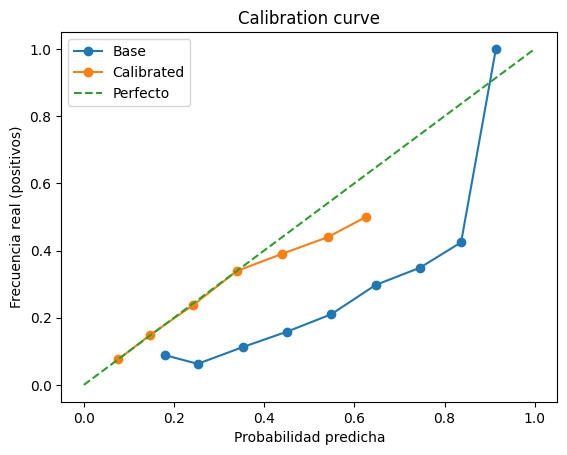

In [13]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Partimos X_train/y_train ya definidos en el notebook
X_tr, X_cal, y_tr, y_cal = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Re-entrenar el pipeline en el subconjunto de entrenamiento
pipe_cal_base = pipe
pipe_cal_base.fit(X_tr, y_tr)

# Calibración usando conjunto de calibración (cv='prefit')
calibrated = CalibratedClassifierCV(pipe_cal_base, cv="prefit", method="sigmoid")
calibrated.fit(X_cal, y_cal)

# Comparación de calibración en test
proba_base = pipe_cal_base.predict_proba(X_test)[:, 1]
proba_cal  = calibrated.predict_proba(X_test)[:, 1]

brier_base = brier_score_loss(y_test, proba_base)
brier_cal  = brier_score_loss(y_test, proba_cal)

print("Brier score (menor es mejor):")
print(f" - Base : {brier_base:.4f}")
print(f" - Calib: {brier_cal:.4f}")

# Curva de calibración
frac_pos_base, mean_pred_base = calibration_curve(y_test, proba_base, n_bins=10)
frac_pos_cal,  mean_pred_cal  = calibration_curve(y_test, proba_cal,  n_bins=10)

plt.figure()
plt.plot(mean_pred_base, frac_pos_base, marker="o", label="Base")
plt.plot(mean_pred_cal,  frac_pos_cal,  marker="o", label="Calibrated")
plt.plot([0,1],[0,1], linestyle="--", label="Perfecto")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real (positivos)")
plt.title("Calibration curve")
plt.legend()
plt.show()


### 13.2 Selección de threshold por costo (FN/FP)

En negocio, **no** siempre conviene usar 0.5. Aquí elegimos el umbral minimizando costo esperado:

- `cost_fn`: costo de **no detectar** un churn real (FN)
- `cost_fp`: costo de **intervenir** a un cliente que no iba a churn (FP)

> Esto explica por qué un threshold puede ser "bajo" (por ejemplo ~0.22): si el costo FN es mucho mayor que FP, conviene ser más agresivos detectando riesgo.

✅ Threshold óptimo por costo: 0.1
Detalle (top 5):


,threshold,tp,fp,fn,tn,cost
0,0.10,334,1246,32,388,1566
1,0.11,326,1173,40,461,1573
2,0.12,315,1065,51,569,1575
3,0.09,343,1345,23,289,1575
4,0.08,349,1418,17,216,1588


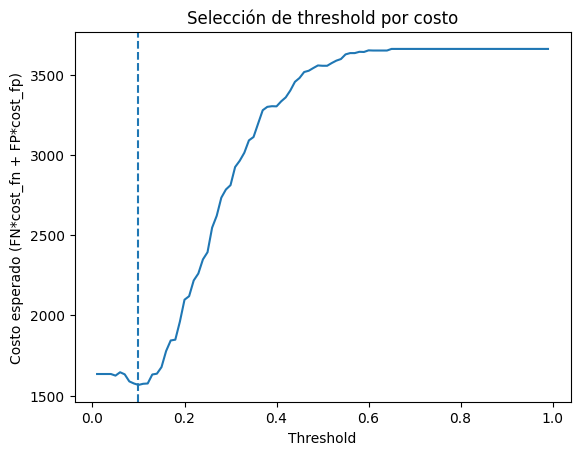

In [14]:
import numpy as np
import pandas as pd

def select_threshold_by_cost(y_true, y_proba, cost_fn=10.0, cost_fp=1.0, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    rows = []
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    for t in grid:
        y_pred = (y_proba >= t).astype(int)
        tp = ((y_pred==1) & (y_true==1)).sum()
        fp = ((y_pred==1) & (y_true==0)).sum()
        fn = ((y_pred==0) & (y_true==1)).sum()
        tn = ((y_pred==0) & (y_true==0)).sum()
        cost = fn*cost_fn + fp*cost_fp
        rows.append({"threshold": t, "tp": tp, "fp": fp, "fn": fn, "tn": tn, "cost": cost})
    df = pd.DataFrame(rows).sort_values("cost").reset_index(drop=True)
    return df

# Ajusta estos costos según tu negocio (ejemplo)
COST_FN = 10   # perder un cliente cuesta más
COST_FP = 1    # contactar/retener cuesta menos

df_cost = select_threshold_by_cost(y_test, proba_cal, cost_fn=COST_FN, cost_fp=COST_FP)
best = df_cost.iloc[0]
THRESHOLD_COST = float(best["threshold"])

print("✅ Threshold óptimo por costo:", round(THRESHOLD_COST, 3))
print("Detalle (top 5):")
display(df_cost.head(5))

# Visual rápido
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df_cost.sort_values("threshold")["threshold"], df_cost.sort_values("threshold")["cost"])
plt.axvline(THRESHOLD_COST, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Costo esperado (FN*cost_fn + FP*cost_fp)")
plt.title("Selección de threshold por costo")
plt.show()


#13.3 SHAP para explicabilidad robusta

Para la demo, SHAP ayuda a explicar **qué variables empujan** la predicción hacia churn/no churn.

- En regresión logística, SHAP es muy rápido (explicador lineal).
- Usamos el `preprocess` para obtener matriz final y nombres de features.

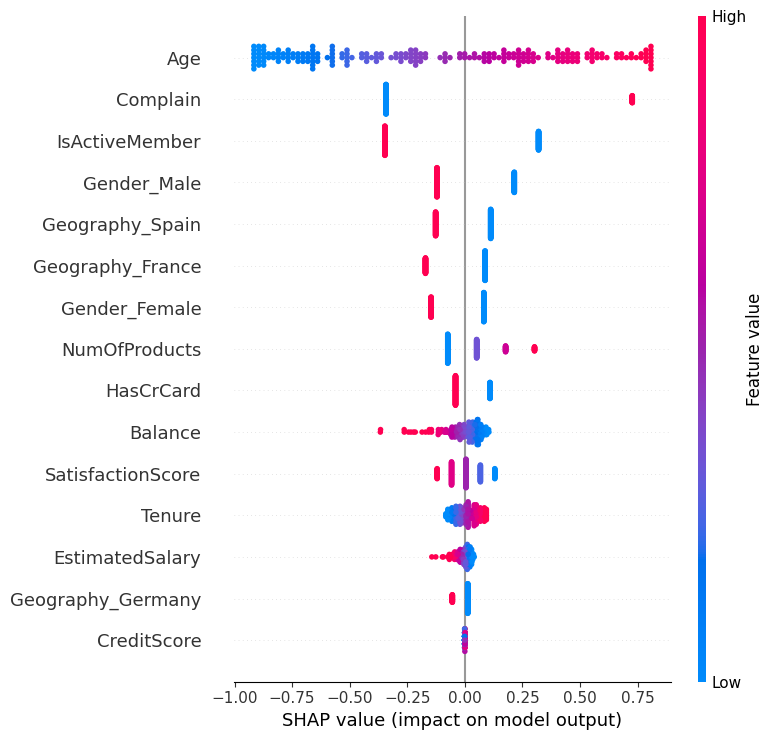

In [15]:
# SHAP (opcional). Si shap no está disponible, esta sección se omite.
try:
    import shap
    import numpy as np

    # Tomamos el modelo ya entrenado dentro del pipeline calibrado base
    model_lr = pipe_cal_base.named_steps.get("model", None)
    if model_lr is None:
        raise ValueError("No se encontró 'model' dentro del pipeline.")

    # Matriz transformada (post-preprocess)
    X_bg = X_tr.sample(min(200, len(X_tr)), random_state=42)
    X_bg_t = preprocess.transform(X_bg)

    # asegurar denso para SHAP si viene sparse
    if hasattr(X_bg_t, "toarray"):
        X_bg_t_dense = X_bg_t.toarray()
    else:
        X_bg_t_dense = np.asarray(X_bg_t)

    feature_names = _get_feature_names(preprocess)

    explainer = shap.LinearExplainer(model_lr, X_bg_t_dense, feature_perturbation="interventional")

    # Explicar un pequeño batch
    X_explain = X_test.sample(min(200, len(X_test)), random_state=42)
    X_explain_t = preprocess.transform(X_explain)
    X_explain_t = X_explain_t.toarray() if hasattr(X_explain_t, "toarray") else np.asarray(X_explain_t)

    shap_values = explainer.shap_values(X_explain_t)

    # Summary plot
    shap.summary_plot(shap_values, features=X_explain_t, feature_names=feature_names, show=True)

except Exception as e:
    print("⚠️ Sección SHAP omitida:", e)


# 13.4 Persistencia de predicciones (DB) + base para endpoint GET

Para Power BI / dashboards vivos, lo ideal es **guardar cada predicción** y exponerla vía **GET**.

Aquí implementamos una persistencia simple en **SQLite** (local) y funciones para:
- `save_prediction(...)`
- `get_predictions_df(...)`

> En backend, esto se convierte en un endpoint GET que consulta la DB.


In [16]:
import sqlite3, json, datetime, pandas as pd
from pathlib import Path

DB_PATH = Path("predictions.db")

def _init_db(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS predictions (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        ts_utc TEXT NOT NULL,
        model_version TEXT,
        threshold REAL,
        forecast INTEGER NOT NULL,
        probability REAL NOT NULL,
        payload_json TEXT
    );
    """)
    conn.commit()
    conn.close()

def save_prediction(payload: dict, forecast: int, probability: float, threshold: float, model_version: str="logreg_smote_v4"):
    _init_db()
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute(
        "INSERT INTO predictions (ts_utc, model_version, threshold, forecast, probability, payload_json) VALUES (?, ?, ?, ?, ?, ?)",
        (
            datetime.datetime.utcnow().isoformat() + "Z",
            model_version,
            float(threshold),
            int(forecast),
            float(probability),
            json.dumps(payload, ensure_ascii=False),
        )
    )
    conn.commit()
    row_id = cur.lastrowid
    conn.close()
    return row_id

def get_predictions_df(limit=1000):
    _init_db()
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(
        f"SELECT * FROM predictions ORDER BY id DESC LIMIT {int(limit)}",
        conn
    )
    conn.close()
    return df

print("✅ DB lista en:", DB_PATH.resolve())


✅ DB lista en: /content/predictions.db


In [17]:
# Ejemplo: guardar una predicción real (usando el contrato v4)

example_payload_v4 = {
  "geography": "Spain",
  "gender": "Male",
  "age": 42,
  "creditScore": 650,
  "balance": 1200.5,
  "estimatedSalary": 45000,
  "tenure": 6,
  "numOfProducts": 2,
  "satisfactionScore": 2,
  "isActiveMember": True,
  "hasCrCard": True,
  "complain": False
}

one = contract_v4_to_df(example_payload_v4)
p = float(calibrated.predict_proba(one)[:,1][0])
forecast_int = int(p >= THRESHOLD_COST)

row_id = save_prediction(example_payload_v4, forecast_int, p, THRESHOLD_COST, model_version="logreg_smote_v4_calibrated")
print("✅ Guardado prediction id:", row_id)

display(get_predictions_df(limit=5))


✅ Guardado prediction id: 1


,id,ts_utc,model_version,threshold,forecast,probability,payload_json
0,1,2026-01-26T01:04:58.095561Z,logreg_smote_v4_calibrated,0.1,0,0.086668,"{""geography"": ""Spain"", ""gender"": ""Male"", ""age""..."


#### Endpoint GET (referencia)

> Esto es **código de referencia** para el backend/microservicio (no se ejecuta aquí necesariamente).

- `GET /predictions?limit=1000` → devuelve histórico
- Power BI consume ese endpoint como fuente Web


In [18]:
# Referencia de endpoint GET (FastAPI).
# En producción, este código vive en el microservicio DS y consulta la misma DB.

fastapi_example = r'''
from fastapi import FastAPI
import sqlite3
import pandas as pd

app = FastAPI()

@app.get("/predictions")
def get_predictions(limit: int = 1000):
    conn = sqlite3.connect("predictions.db")
    df = pd.read_sql_query(
        f"SELECT * FROM predictions ORDER BY id DESC LIMIT {int(limit)}",
        conn
    )
    conn.close()
    return df.to_dict(orient="records")
'''
print(fastapi_example)



from fastapi import FastAPI
import sqlite3
import pandas as pd

app = FastAPI()

@app.get("/predictions")
def get_predictions(limit: int = 1000):
    conn = sqlite3.connect("predictions.db")
    df = pd.read_sql_query(
        f"SELECT * FROM predictions ORDER BY id DESC LIMIT {int(limit)}",
        conn
    )
    conn.close()
    return df.to_dict(orient="records")



### 13.5 Monitoreo (drift) + versionado (MLflow)

Esto es una base simple de monitoreo:
- Guardamos un **baseline** de distribución en train
- Calculamos **PSI** en un batch nuevo (ej. test / producción)

Y además versionamos con MLflow:
- parámetros (modelo, SMOTE, costos)
- métricas
- artefactos (metadata + modelo)


In [19]:
# --- Drift básico (vNext): baseline + reporte (PSI num / L1 categórico) ---
# Nota: trabajamos sobre el espacio "crudo" (features DS antes de one-hot).
# Esto evita KeyError y nos da una señal estable de cambios.

import numpy as np
import pandas as pd
import json
from pathlib import Path

# Guardamos dentro de models/ para mantener orden de artefactos
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_PATH = MODELS_DIR / "baseline_stats.json"

def psi(expected, actual, buckets=10, eps=1e-6):
    """PSI para variables numéricas usando cuantiles del baseline."""
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)
    if expected.size == 0 or actual.size == 0:
        return float("nan")

    quantiles = np.quantile(expected, np.linspace(0, 1, buckets + 1))
    # evitar bordes iguales / bins degenerados
    quantiles[0] = -np.inf
    quantiles[-1] = np.inf

    exp_counts, _ = np.histogram(expected, bins=quantiles)
    act_counts, _ = np.histogram(actual, bins=quantiles)

    exp_perc = exp_counts / max(exp_counts.sum(), 1)
    act_perc = act_counts / max(act_counts.sum(), 1)

    exp_perc = np.clip(exp_perc, eps, 1)
    act_perc = np.clip(act_perc, eps, 1)

    return float(np.sum((act_perc - exp_perc) * np.log(act_perc / exp_perc)))

def build_baseline(df: pd.DataFrame, num_cols, cat_cols):
    baseline = {"numeric": {}, "categorical": {}}
    for c in num_cols:
        if c in df.columns:
            baseline["numeric"][c] = {"values": df[c].dropna().astype(float).tolist()}
    for c in cat_cols:
        if c in df.columns:
            vc = df[c].fillna("NA").astype(str).value_counts(normalize=True).to_dict()
            baseline["categorical"][c] = vc
    return baseline

def drift_report(baseline: dict, df_new: pd.DataFrame, num_cols, cat_cols):
    report = {"psi_numeric": {}, "cat_l1": {}}

    # PSI numérico
    for c in num_cols:
        if c not in df_new.columns:
            continue
        base_vals = np.asarray(baseline.get("numeric", {}).get(c, {}).get("values", []), dtype=float)
        new_vals = df_new[c].dropna().astype(float).to_numpy()
        report["psi_numeric"][c] = psi(base_vals, new_vals, buckets=10)

    # Distancia L1 categórica
    for c in cat_cols:
        if c not in df_new.columns:
            continue
        base = baseline.get("categorical", {}).get(c, {})
        new = df_new[c].fillna("NA").astype(str).value_counts(normalize=True).to_dict()
        keys = set(base) | set(new)
        l1 = sum(abs(base.get(k, 0.0) - new.get(k, 0.0)) for k in keys)
        report["cat_l1"][c] = float(l1)

    return report

# -----------------------------
# Selección robusta de columnas (detecta esquema del DataFrame)
# -----------------------------
NUM_COLS_PASCAL = ["Age","CreditScore","Balance","EstimatedSalary","Tenure","NumOfProducts","SatisfactionScore"]
CAT_COLS_PASCAL = ["Geography","Gender"]
BIN_COLS_PASCAL = ["IsActiveMember","HasCrCard","Complain"]

NUM_COLS_CAMEL  = ["age","creditScore","balance","estimatedSalary","tenure","numOfProducts","satisfactionScore"]
CAT_COLS_CAMEL  = ["geography","gender"]
BIN_COLS_CAMEL  = ["isActiveMember","hasCrCard","complain"]

def pick_schema_cols(df: pd.DataFrame):
    if all(c in df.columns for c in (NUM_COLS_PASCAL + CAT_COLS_PASCAL + BIN_COLS_PASCAL)):
        return NUM_COLS_PASCAL, CAT_COLS_PASCAL, BIN_COLS_PASCAL
    if all(c in df.columns for c in (NUM_COLS_CAMEL + CAT_COLS_CAMEL + BIN_COLS_CAMEL)):
        return NUM_COLS_CAMEL, CAT_COLS_CAMEL, BIN_COLS_CAMEL

    # fallback: tomar lo que exista sin romper
    num_ = [c for c in (NUM_COLS_PASCAL + NUM_COLS_CAMEL) if c in df.columns]
    cat_ = [c for c in (CAT_COLS_PASCAL + CAT_COLS_CAMEL) if c in df.columns]
    bin_ = [c for c in (BIN_COLS_PASCAL + BIN_COLS_CAMEL) if c in df.columns]
    return num_, cat_, bin_

# -----------------------------
# Baseline desde X_train (raw features antes de one-hot)
# Requiere que X_train y X_test existan en el notebook (celdas anteriores).
# -----------------------------
NUM_COLS, CAT_COLS, BIN_COLS = pick_schema_cols(X_train)
cols_used = NUM_COLS + CAT_COLS + BIN_COLS
assert len(cols_used) > 0, "No se encontraron columnas v4 reconocibles en X_train. Revisa el pipeline/renombrado."

baseline = build_baseline(X_train[cols_used], num_cols=NUM_COLS + BIN_COLS, cat_cols=CAT_COLS)
BASELINE_PATH.write_text(json.dumps(baseline, ensure_ascii=False, indent=2), encoding="utf-8")
print("✅ Baseline guardado:", BASELINE_PATH.resolve())

# Reporte drift usando X_test como "nuevo batch" (mismo esquema)
report = drift_report(baseline, X_test[cols_used], num_cols=NUM_COLS + BIN_COLS, cat_cols=CAT_COLS)

print("\n📌 PSI (num+bin): >0.2 moderado, >0.5 alto (regla práctica)")
for k, v in sorted(report["psi_numeric"].items(), key=lambda x: (-(x[1] if x[1]==x[1] else -1)) )[:10]:
    print(f" - {k}: {v:.3f}")

print("")
print("Cambio categórico L1 (más alto = más cambio)")
cat_changes = report.get("cat_l1", {})
if isinstance(cat_changes, dict) and len(cat_changes) > 0:
    for k, v in sorted(cat_changes.items(), key=lambda x: -x[1])[:10]:
        print(f" - {k}: {float(v):.3f}")
else:
    print(" (sin variables categóricas en este dataset)")


✅ Baseline guardado: /content/models/baseline_stats.json

📌 PSI (num+bin): >0.2 moderado, >0.5 alto (regla práctica)
 - Balance: 0.009
 - Age: 0.006
 - EstimatedSalary: 0.006
 - Tenure: 0.005
 - CreditScore: 0.004
 - SatisfactionScore: 0.003
 - NumOfProducts: 0.001
 - IsActiveMember: 0.001
 - HasCrCard: 0.000
 - Complain: 0.000

Cambio categórico L1 (más alto = más cambio)
 - Gender: 0.034
 - Geography: 0.014


In [20]:
# MLflow (opcional). Si no está disponible, se omite.
try:
    import mlflow
    import mlflow.sklearn

    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("ChurnInsight_v4_LogReg_SMOTE")

    with mlflow.start_run(run_name="logreg_smote_v4_calibrated"):
        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("smote", True)
        mlflow.log_param("calibration", "sigmoid")
        mlflow.log_param("cost_fn", COST_FN)
        mlflow.log_param("cost_fp", COST_FP)
        mlflow.log_param("threshold_cost", THRESHOLD_COST)

        # métricas
        from sklearn.metrics import roc_auc_score, average_precision_score
        mlflow.log_metric("roc_auc_base", float(roc_auc_score(y_test, proba_base)))
        mlflow.log_metric("roc_auc_cal",  float(roc_auc_score(y_test, proba_cal)))
        mlflow.log_metric("brier_base", float(brier_base))
        mlflow.log_metric("brier_cal",  float(brier_cal))
        mlflow.log_metric("pr_auc_cal", float(average_precision_score(y_test, proba_cal)))

        # artefactos: metadata y baseline
        mlflow.log_artifact(str(METADATA_PATH))
        mlflow.log_artifact(str(BASELINE_PATH))

        # modelo calibrado
        mlflow.sklearn.log_model(calibrated, "model_calibrated")

    print("✅ MLflow run registrado en ./mlruns")
except Exception as e:
    print("⚠️ MLflow omitido:", e)


2026/01/26 01:04:58 INFO mlflow.tracking.fluent: Experiment with name 'ChurnInsight_v4_LogReg_SMOTE' does not exist. Creating a new experiment.
2026/01/26 01:05:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ MLflow run registrado en ./mlruns




Al ejecutar esta sección, tendrás artefactos útiles para producción/demos:

- `models/...joblib` (modelo base)
- `metadata_modelo.json` (contrato, threshold, features)
- `predictions.db` (histórico local)
- `baseline_stats.json` (baseline para drift)
- `mlruns/` (versionado local MLflow, opcional)


